In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For drug identification (judgement ②), how accurately does each model in the roster extract the drugs mentioned in a post — precision AND recall, against Opus-as-truth — and how do the models diverge?"

*Judgement ② of 11 · the factual template with a recall dimension: F1 vs the validated judge, a precision–recall map, an N×N divergence heatmap, and a price-aware scorecard. Numbers computed from the run.*

In [2]:

import json
from itertools import combinations

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j2_drugid_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]
exts, judge, posts = RUNS["extractions"], RUNS["judge"], RUNS["posts"]
CAND = MAN["candidate_models"]
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.909, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.12, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.195, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.12, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
def short(m): return m.split("/")[-1]

JUDGE = {j["sample_id"]: j for j in judge}
# gold present-set per post = extractions Opus ruled correct + drugs Opus said everyone missed
gold = {s: ({d for d, v in j["verdicts"].items() if v == "correct"} | set(j.get("missed", [])))
        for s, j in JUDGE.items()}
def str_in_post(d, s): return len(d) >= 3 and d in posts[s].lower()
def jacc(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else np.nan

# per (model, post)
rows = []
for e in exts:
    m, s, ext = e["model"], e["sample_id"], e["drugs"]
    verd = JUDGE.get(s, {}).get("verdicts", {})
    correct = [d for d in ext if verd.get(d) == "correct"]
    strhit = [d for d in ext if str_in_post(d, s)]
    rows.append(dict(model=m, mshort=short(m), sample_id=s, n_ext=len(ext),
                     n_correct=len(correct), n_strhit=len(strhit), n_gold=len(gold.get(s, set()))))
df = pd.DataFrame(rows)

# per-model micro-pooled precision / recall / F1 / string-precision + price
ext_sets = {(e["model"], e["sample_id"]): set(e["drugs"]) for e in exts}
sample_ids = sorted(posts)
mr = []
for m in CAND:
    sub = df[df.model == m]
    ext_tot, corr_tot = int(sub.n_ext.sum()), int(sub.n_correct.sum())
    gold_tot, str_tot = int(sub.n_gold.sum()), int(sub.n_strhit.sum())
    prec = corr_tot / ext_tot if ext_tot else np.nan
    rec = corr_tot / gold_tot if gold_tot else np.nan
    f1 = 2 * prec * rec / (prec + rec) if (prec and rec and prec + rec) else np.nan
    mr.append(dict(model=m, mshort=short(m), precision=prec, recall=rec, f1=f1,
                   str_prec=(str_tot / ext_tot if ext_tot else np.nan),
                   n_ext_total=ext_tot, n_correct=corr_tot,
                   mean_ext=sub.n_ext.mean(), price=PRICES.get(m, np.nan)))
MS = pd.DataFrame(mr)
FAILED = MS[MS.n_ext_total == 0].mshort.tolist()
MS = MS[MS.n_ext_total > 0].reset_index(drop=True)
OK = MS.model.tolist()

# N×N divergence (mean Jaccard of extraction sets across posts)
MAT = pd.DataFrame(index=[short(m) for m in OK], columns=[short(m) for m in OK], dtype=float)
for x in OK:
    for y in OK:
        MAT.loc[short(x), short(y)] = 1.0 if x == y else np.nanmean(
            [jacc(ext_sets.get((x, s), set()), ext_sets.get((y, s), set())) for s in sample_ids])
MS["outlier"] = [1 - np.nanmean([MAT.loc[short(m), short(o)] for o in OK if o != m]) for m in OK]

_best = MS.sort_values("f1", ascending=False).iloc[0]
_bestP = MS.sort_values("precision", ascending=False).iloc[0]
_bestR = MS.sort_values("recall", ascending=False).iloc[0]
_fg = (MS.str_prec - MS.precision).mean()
display(Markdown(f"""
**Abstract.** Drug identification (judgement ②) reads a post and returns the *set* of drugs mentioned —
`extract_batch`, the pipeline's second step. A missed drug is a lost treatment report; a hallucinated one
is a phantom report. We test the roster the way the design specifies: **{len(OK)} models** extract drugs
from **{MAN['n_posts']} posts** (temp 0), scored for **precision and recall against Opus-as-judge** (which
reads the post, rules each extraction correct/hallucinated, and lists drugs everyone missed), with a
string-in-post floor and an N×N divergence map beside it. **{_best.mshort}** has the best balance
(F1={_best.f1:.2f}); the roster splits into precise-but-cautious ({_bestP.mshort}, {_bestP.precision:.0%}
precision) and thorough-but-eager ({_bestR.mshort}, {_bestR.recall:.0%} recall) extractors. The string-in-post
floor is only a noisy corroborator (net {_fg:+.0%} vs the judge): it misses correct abbreviations
(LDN → "low dose naltrexone") and admits the odd non-treatment mention ("histamine" as a condition), so
Opus-as-judge — reading for *treatment* mention and resolving abbreviations — is the standard, not the floor.
{(' No parseable extractions from: ' + ', '.join(FAILED) + '.') if FAILED else ''}
"""))



**Abstract.** Drug identification (judgement ②) reads a post and returns the *set* of drugs mentioned —
`extract_batch`, the pipeline's second step. A missed drug is a lost treatment report; a hallucinated one
is a phantom report. We test the roster the way the design specifies: **22 models** extract drugs
from **40 posts** (temp 0), scored for **precision and recall against Opus-as-judge** (which
reads the post, rules each extraction correct/hallucinated, and lists drugs everyone missed), with a
string-in-post floor and an N×N divergence map beside it. **gpt-5-mini** has the best balance
(F1=0.79); the roster splits into precise-but-cautious (grok-4.5, 99%
precision) and thorough-but-eager (gpt-5-mini, 71% recall) extractors. The string-in-post
floor is only a noisy corroborator (net -5% vs the judge): it misses correct abbreviations
(LDN → "low dose naltrexone") and admits the odd non-treatment mention ("histamine" as a condition), so
Opus-as-judge — reading for *treatment* mention and resolving abbreviations — is the standard, not the floor.



## 1. What this judgement is, and why correctness matters

`extract_batch` reads a post and returns the set of drugs, supplements, and treatments it mentions. Every downstream sentiment report is keyed to a drug this step found, so its errors bound the whole pipeline: a **missed** drug silently drops a treatment report; a **hallucinated** drug injects a phantom one. Because a post has a definite set of drugs, this is factual — measured by **precision** (are the extracted drugs really there?) and **recall** (did it find them all?), not agreement.

## 2. Two truth sources — and why the objective floor is not enough here

For ① alias, the objective source (RxNorm) missed valid informal aliases. For ② the objective source — does the extracted drug literally appear in the post? — is noisy in *both* directions: it misses correct abbreviations and paraphrases (a model extracting 'low dose naltrexone' from 'LDN'), and it counts drug names that appear as the author's **condition** rather than a treatment ('histamine issues'). Neither error dominates, so string-presence can't rank models — Opus-as-judge, which reads for *treatment* mention and resolves abbreviations, is the standard; the floor only corroborates.

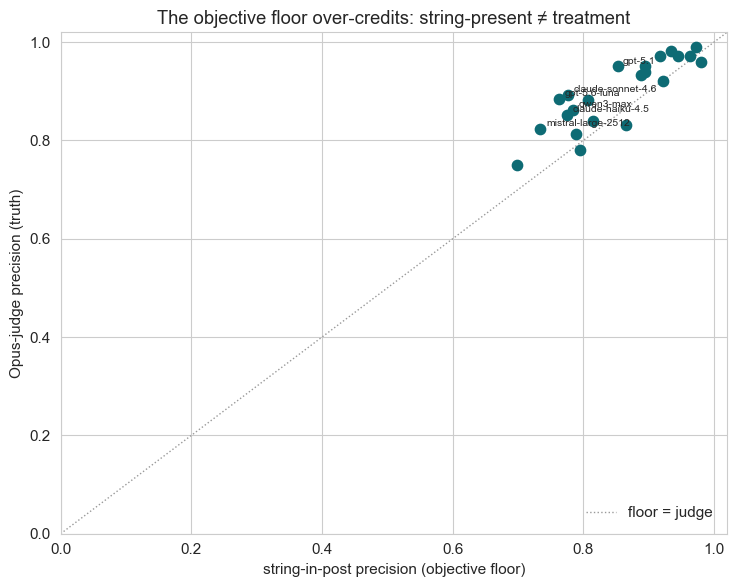

**What this shows:** the floor tracks the judge on average (net string − judge = -5%) but diverges case by case. **18** models sit above the diagonal — the judge credits correct abbreviations and paraphrases the literal string-match misses (e.g. 'low dose naltrexone' extracted from 'LDN'); **3** sit below, where the floor counts a drug name used as a condition, not a treatment ('histamine issues'). Neither cancels cleanly, so the string floor corroborates but cannot rank — the validated judge is the standard.

In [3]:

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(MS.str_prec, MS.precision, s=55, color="#0e6b74", zorder=3)
lim = [0, 1.02]
ax.plot(lim, lim, ls=":", color="#999", lw=1, label="floor = judge")
_gap = (MS.str_prec - MS.precision).abs()
for i in _gap.nlargest(6).index:
    r = MS.loc[i]
    ax.annotate(r.mshort, (r.str_prec, r.precision), fontsize=7.5, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("string-in-post precision (objective floor)"); ax.set_ylabel("Opus-judge precision (truth)")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.legend(frameon=False, loc="lower right")
ax.set_title("The objective floor over-credits: string-present ≠ treatment")
fig.tight_layout(); plt.show()
gap = (MS.str_prec - MS.precision).mean()
above = int((MS.precision > MS.str_prec).sum()); below = int((MS.precision < MS.str_prec).sum())
display(Markdown(
  f"**What this shows:** the floor tracks the judge on average (net string − judge = {gap:+.0%}) but diverges "
  f"case by case. **{above}** models sit above the diagonal — the judge credits correct abbreviations and "
  f"paraphrases the literal string-match misses (e.g. 'low dose naltrexone' extracted from 'LDN'); **{below}** "
  f"sit below, where the floor counts a drug name used as a condition, not a treatment ('histamine issues'). "
  f"Neither cancels cleanly, so the string floor corroborates but cannot rank — the validated judge is the standard."))


## 3. Correctness scorecard — the verdict

F1 against Opus-as-truth per model (precision × recall), sorted. F1 is the headline because both failure modes hurt the pipeline; precision and recall separately are in the table.

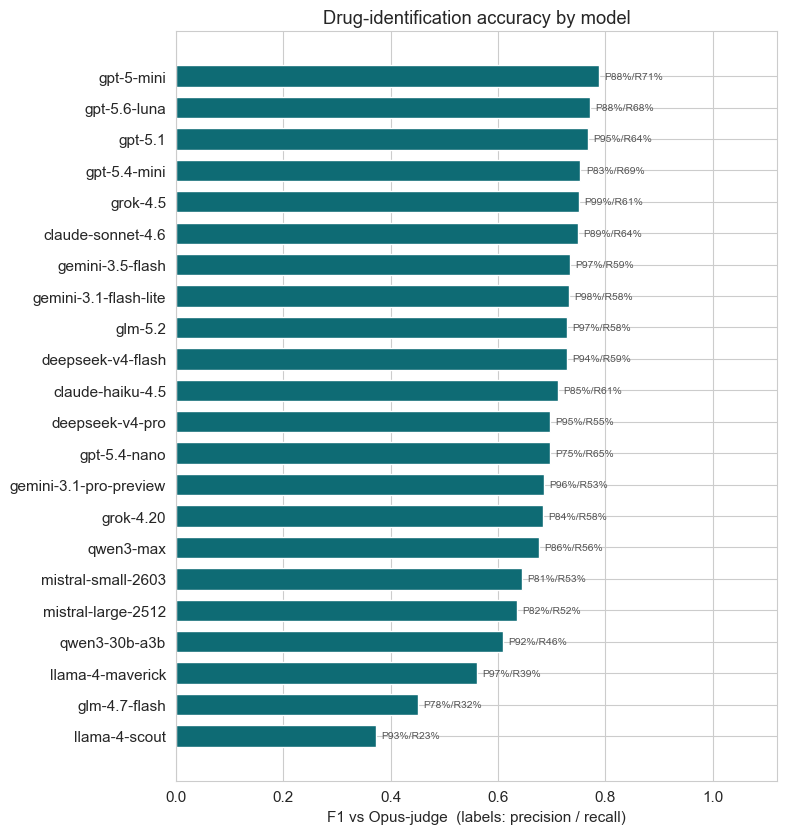

model,F1,precision,recall,string floor,drugs/post,$/1M in
gpt-5-mini,0.79,88%,71%,81%,3.6,$0.25
gpt-5.6-luna,0.77,88%,68%,76%,3.5,$1
gpt-5.1,0.77,95%,64%,85%,3.0,$1.25
gpt-5.4-mini,0.75,83%,69%,87%,3.7,$0.75
grok-4.5,0.75,99%,61%,97%,2.8,$2
claude-sonnet-4.6,0.75,89%,64%,78%,3.2,$3
gemini-3.5-flash,0.73,97%,59%,96%,2.7,$1.5
gemini-3.1-flash-lite,0.73,98%,58%,93%,2.7,$0.25
glm-5.2,0.73,97%,58%,94%,2.7,$0.909
deepseek-v4-flash,0.73,94%,59%,89%,2.8,$0.098


In [4]:

d = MS.sort_values("f1", ascending=True)
fig, ax = plt.subplots(figsize=(8, 0.34*len(d) + 1))
ax.barh(d.mshort, d.f1, color="#0e6b74", height=0.68)
for y, (_, r) in enumerate(d.iterrows()):
    ax.text(r.f1 + 0.01, y, f"P{r.precision:.0%}/R{r.recall:.0%}", va="center", fontsize=7.5, color="#555")
ax.set_xlim(0, 1.12); ax.set_xlabel("F1 vs Opus-judge  (labels: precision / recall)")
ax.set_title("Drug-identification accuracy by model"); fig.tight_layout(); plt.show()

tbl = MS.sort_values("f1", ascending=False)[["mshort","f1","precision","recall","str_prec","mean_ext","price"]].copy()
tbl["f1"] = tbl["f1"].round(2)
for c in ["precision","recall","str_prec"]: tbl[c] = (tbl[c]*100).round(0).astype("Int64").astype(str)+"%"
tbl["mean_ext"] = tbl["mean_ext"].round(1)
tbl["price"] = tbl["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
tbl.columns = ["model","F1","precision","recall","string floor","drugs/post","$/1M in"]
display(HTML("<b>Per-model correctness</b>" + tbl.to_html(index=False)))


## 4. Counterintuitive: the precision–recall split

There is no single 'best extractor' — models sit on a tradeoff. Cautious models extract only the obvious drugs (high precision, low recall — they drop the ones needing inference); eager models grab everything drug-shaped (high recall, low precision — they hallucinate). Which end you want depends on whether a phantom report or a missed report costs the pipeline more.

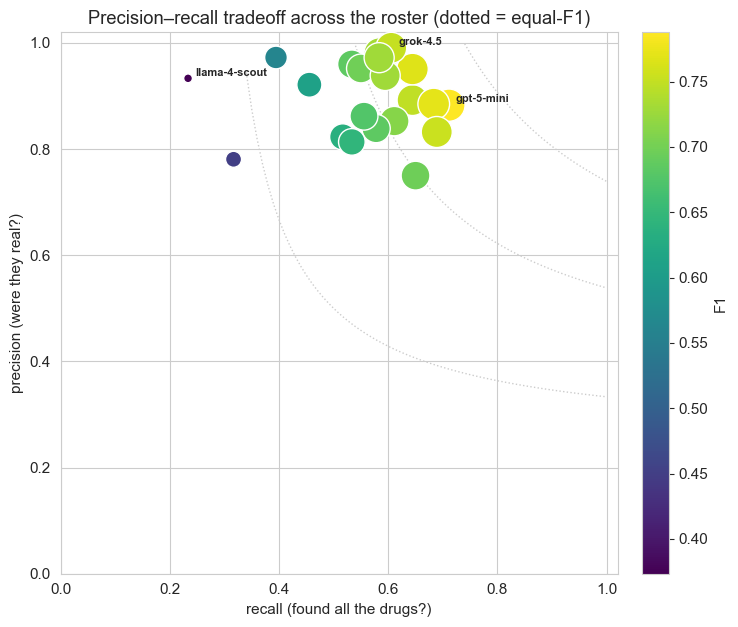

**What this shows:** models spread along the tradeoff, not a single quality axis. The most **precise** is **grok-4.5** (99%); the most **thorough** is **gpt-5-mini** (71%). For clustering, recall usually matters more — a missed drug is a missing data point — so a model in the high-recall corner with acceptable precision is the safer default.

In [5]:

fig, ax = plt.subplots(figsize=(7.5, 6.4))
sizes = 40 + 500 * (MS.f1 - MS.f1.min()) / (MS.f1.max() - MS.f1.min() + 1e-9)
sc = ax.scatter(MS.recall, MS.precision, s=sizes, c=MS.f1, cmap="viridis", zorder=3, edgecolor="white")
_notable = {MS.precision.idxmax(), MS.recall.idxmax(), MS.f1.idxmax(), MS.f1.idxmin()}
for i in _notable:
    r = MS.loc[i]
    ax.annotate(r.mshort, (r.recall, r.precision), fontsize=8, fontweight="bold", xytext=(5, 2), textcoords="offset points")
for f in [0.5, 0.7, 0.85]:  # F1 iso-contours
    rr = np.linspace(0.01, 1, 100); pp = f * rr / (2 * rr - f)
    ok = (pp > 0) & (pp <= 1); ax.plot(rr[ok], pp[ok], ls=":", color="#ccc", lw=1)
ax.set_xlabel("recall (found all the drugs?)"); ax.set_ylabel("precision (were they real?)")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="F1")
ax.set_title("Precision–recall tradeoff across the roster (dotted = equal-F1)")
fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** models spread along the tradeoff, not a single quality axis. The most **precise** is "
  f"**{MS.sort_values('precision', ascending=False).iloc[0].mshort}** ({MS.precision.max():.0%}); the most "
  f"**thorough** is **{MS.sort_values('recall', ascending=False).iloc[0].mshort}** ({MS.recall.max():.0%}). "
  f"For clustering, recall usually matters more — a missed drug is a missing data point — so a model in the "
  f"high-recall corner with acceptable precision is the safer default."))


## 5. Comparing the models to each other — divergence map

Mean Jaccard of extraction sets between every pair of models (1 = identical). It clusters the roster into behaviour groups and flags outliers — a diagnostic, never a correctness verdict (models can agree on the same misses).

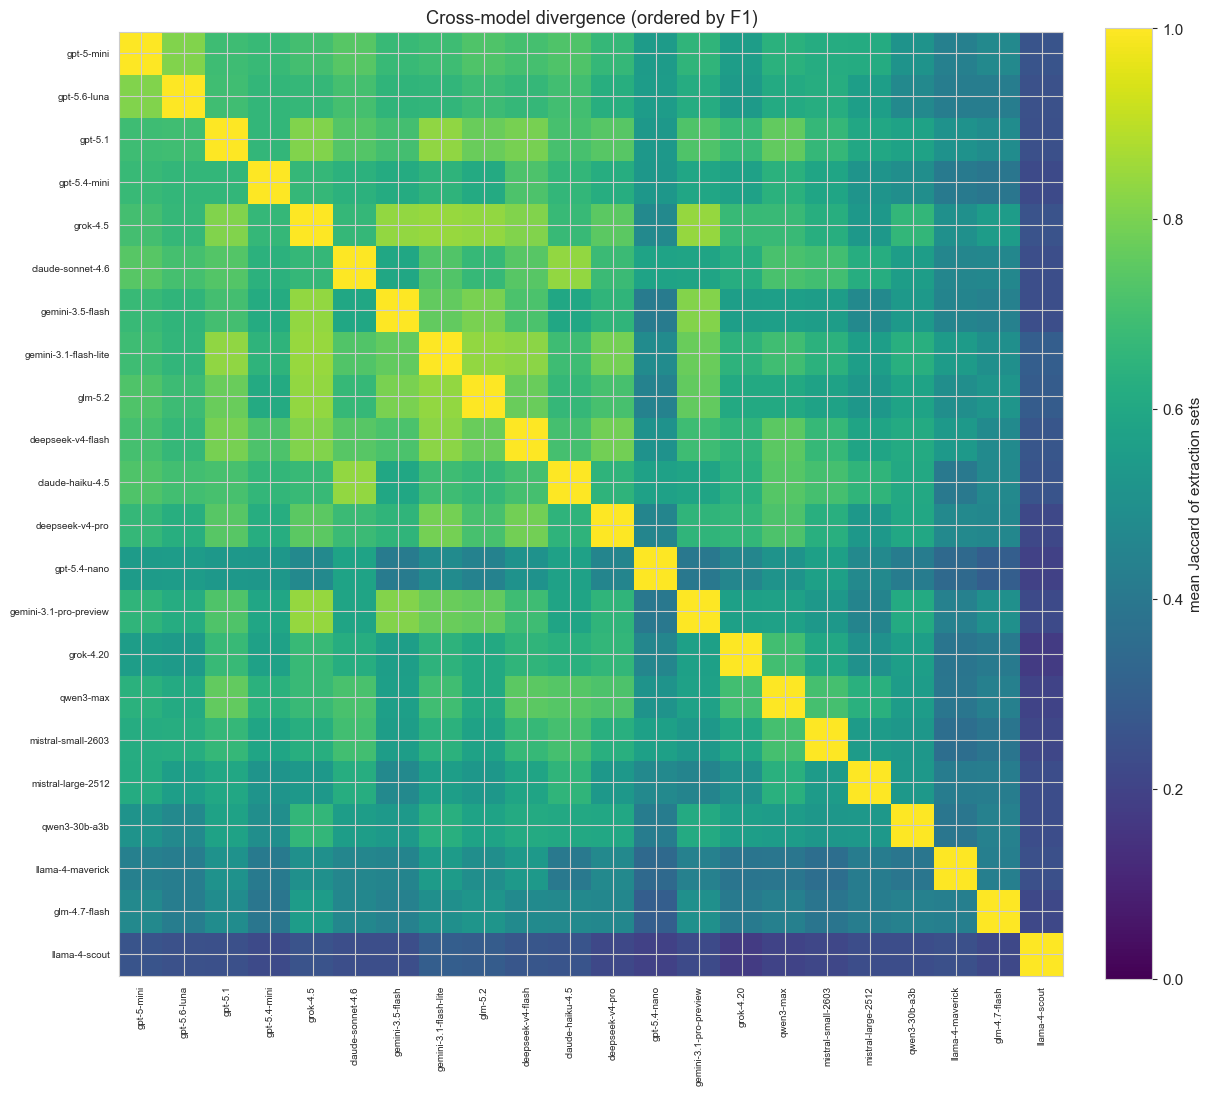

model,outlier (1 − mean agreement),F1
llama-4-scout,0.76,0.37
llama-4-maverick,0.57,0.56
glm-4.7-flash,0.56,0.45
gpt-5.4-nano,0.54,0.70
mistral-large-2512,0.48,0.63
qwen3-30b-a3b,0.47,0.61
grok-4.20,0.44,0.68
mistral-small-2603,0.43,0.64


**What this shows:** the roster shares a mean **57%** extraction overlap — models genuinely differ on which borderline mentions count as drugs. Read outliers against §3: a divergent low-F1 model is a problem; a divergent high-F1 one just draws the drug boundary differently.

In [6]:

order = MS.sort_values("f1", ascending=False).mshort.tolist()
M = MAT.reindex(index=order, columns=order).astype(float)
fig, ax = plt.subplots(figsize=(0.42*len(order) + 3, 0.42*len(order) + 2))
im = ax.imshow(M.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean Jaccard of extraction sets")
ax.set_title("Cross-model divergence (ordered by F1)"); fig.tight_layout(); plt.show()
od = MS.sort_values("outlier", ascending=False)[["mshort","outlier","f1"]].head(8).copy()
od["outlier"] = od["outlier"].round(2); od["f1"] = od["f1"].round(2)
od.columns = ["model","outlier (1 − mean agreement)","F1"]
display(HTML("<b>Most divergent models</b>" + od.to_html(index=False)))
display(Markdown(
  f"**What this shows:** the roster shares a mean "
  f"**{np.nanmean(MAT.values[np.triu_indices(len(order),1)]):.0%}** extraction overlap — models genuinely "
  f"differ on which borderline mentions count as drugs. Read outliers against §3: a divergent low-F1 model is "
  f"a problem; a divergent high-F1 one just draws the drug boundary differently."))


## 6. Conclusion & scorecard — F1 per dollar

The full scorecard and the design's payoff: the cheapest model whose accuracy is close to the best.

In [7]:

best_f1 = MS.f1.max()
elig = MS[MS.f1 >= best_f1 - 0.05]
pick = elig.sort_values("price").iloc[0] if elig.price.notna().any() else MS.sort_values("f1", ascending=False).iloc[0]
sc = MS.sort_values("f1", ascending=False)[["mshort","f1","precision","recall","outlier","mean_ext","price"]].copy()
sc["f1"] = sc["f1"].round(2)
for c in ["precision","recall"]: sc[c] = (sc[c]*100).round(0).astype("Int64").astype(str)+"%"
sc["outlier"] = sc["outlier"].round(2); sc["mean_ext"] = sc["mean_ext"].round(1)
sc["price"] = sc["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
sc.columns = ["model","F1","precision","recall","divergence","drugs/post","$/1M in"]
display(HTML("<b>② drug-ID — full scorecard</b>" + sc.to_html(index=False)))
lines = [
  f"- **Best F1:** {MS.sort_values('f1', ascending=False).iloc[0].mshort} ({best_f1:.2f}) — the accuracy anchor.",
  f"- **Best value (F1 per dollar):** **{pick.mshort}** — F1 {pick.f1:.2f} at ${pick.price:g}/1M input"
  + (", within 5 points of the best while cheaper." if pick.f1 < best_f1 else "."),
  f"- **Precision and recall trade off** — pick the end that matches the cost of a phantom vs a missed report; "
  f"for clustering, lean recall.",
  f"- **The string floor is too noisy to rank** (it misses correct paraphrases and counts non-treatment "
  f"mentions), so Opus-as-judge is the standard here, not the floor.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,F1,precision,recall,divergence,drugs/post,$/1M in
gpt-5-mini,0.79,88%,71%,0.38,3.6,$0.25
gpt-5.6-luna,0.77,88%,68%,0.40,3.5,$1
gpt-5.1,0.77,95%,64%,0.34,3.0,$1.25
gpt-5.4-mini,0.75,83%,69%,0.42,3.7,$0.75
grok-4.5,0.75,99%,61%,0.33,2.8,$2
claude-sonnet-4.6,0.75,89%,64%,0.37,3.2,$3
gemini-3.5-flash,0.73,97%,59%,0.40,2.7,$1.5
gemini-3.1-flash-lite,0.73,98%,58%,0.33,2.7,$0.25
glm-5.2,0.73,97%,58%,0.36,2.7,$0.909
deepseek-v4-flash,0.73,94%,59%,0.33,2.8,$0.098


### Verdict

- **Best F1:** gpt-5-mini (0.79) — the accuracy anchor.
- **Best value (F1 per dollar):** **gpt-5-mini** — F1 0.79 at $0.25/1M input.
- **Precision and recall trade off** — pick the end that matches the cost of a phantom vs a missed report; for clustering, lean recall.
- **The string floor is too noisy to rank** (it misses correct paraphrases and counts non-treatment mentions), so Opus-as-judge is the standard here, not the floor.

## 7. Research limitations

- **The judge validation is weaker than ①.** RxNorm gave a clean external check on the alias judge; for ②
  the only objective anchor (string-in-post) is too loose, so we cannot cross-check Opus as tightly. A proper
  ② judge validation needs a second frontier model to review Opus's verdicts (the GT-review step, deferred).
- **Opus-as-truth is silver** — on genuinely ambiguous mentions ("an oral antibiotic", a drug named as a
  condition) it is a judgment, and it defines both the precision standard and the recall gold, so a
  systematic Opus blind spot would not show up here.
- **Posts** are 40 IRR-frame posts (100–800 chars); recall on longer, drug-denser posts may differ, and the
  frame excludes the corpus's long tail.
- **Price** is input $/1M and ignores output/latency — an order-of-magnitude signal.
- Measures the correctness of a measurement step, not any treatment effect.

In [8]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","judge (truth)","truth sources",
           "posts","temperature","skill version"],
  "value": [MAN["generated_utc"], MAN["judgement"], f'{len(CAND)} ({len(OK)} produced extractions)',
            MAN["judge_model"], ", ".join(MAN["truth_sources"]), MAN["n_posts"], MAN["temperature"],
            "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the behaviour of a measurement pipeline and model knowledge, not '
             'population-level treatment effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-17T23:41:22.236310+00:00
judgement,2_drug_identification
candidate models,22 (22 produced extractions)
judge (truth),anthropic/claude-opus-4.8
truth sources,"string_in_post, opus_judge"
posts,40
temperature,0.0
skill version,research-assistant v2
